# 100+ Years Old Weather Stations - Extreme Heat Days
This notebook calculates the number of extremely hot days (maximum temperature > 32°C) per year for all weather stations with at least 100 years of data. The results are visualized as bar charts to show how the frequency of extreme heat has evolved over the last century.

In [1]:
import pyarrow.dataset as ds
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load dataset
dataset = ds.dataset('../data/dwd_historical_lake', format='parquet', partitioning='hive')

# Find stations with >= 100 years
df_meta = dataset.to_table(columns=['Station_ID', 'Date']).to_pandas()
summary = df_meta.groupby('Station_ID').size()
stations_100 = summary[summary / 365.25 >= 100].index.tolist()

print(f"Processing extreme heat days for {len(stations_100)} stations with >= 100 years of history...")

import io
import requests

print("Fetching station names...")
url = 'https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/KL_Tageswerte_Beschreibung_Stationen.txt'
response = requests.get(url)
response.encoding = 'latin-1'
col_specs = [(0, 5), (6, 14), (15, 23), (24, 38), (39, 50), (51, 60), (61, 102), (102, 140)]
col_names = ["Station_ID", "Start_Date", "End_Date", "Altitude", "Latitude", "Longitude", "Station_Name", "Bundesland"]
df_meta_names = pd.read_fwf(io.StringIO(response.text), skiprows=2, names=col_names, colspecs=col_specs, dtype={"Station_ID": str})
df_meta_names['Station_ID'] = df_meta_names['Station_ID'].str.zfill(5)
df_meta_names['Station_Name'] = df_meta_names['Station_Name'].str.strip()
name_dict = df_meta_names.set_index('Station_ID')['Station_Name'].to_dict()


Processing extreme heat days for 47 stations with >= 100 years of history...
Fetching station names...


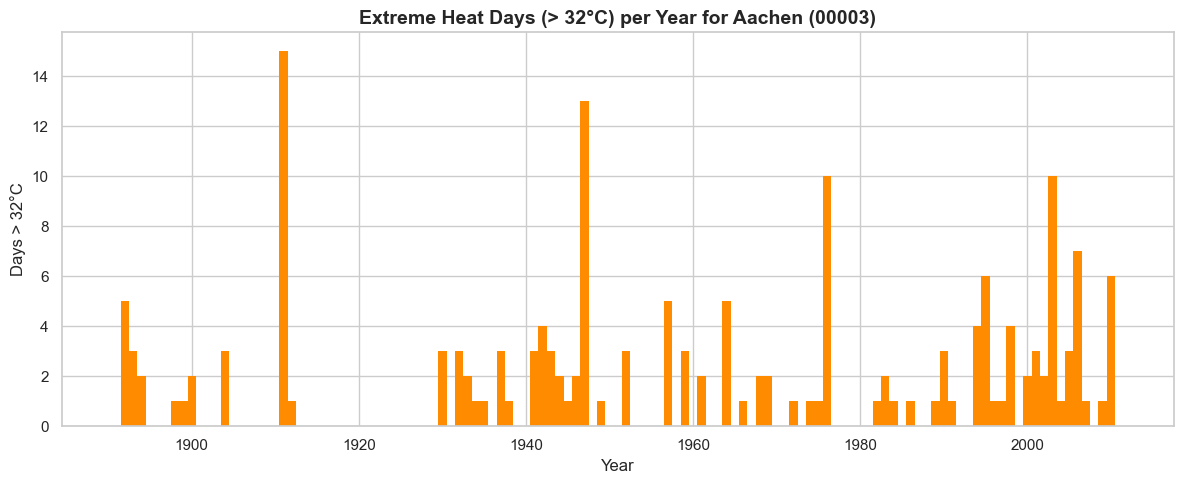

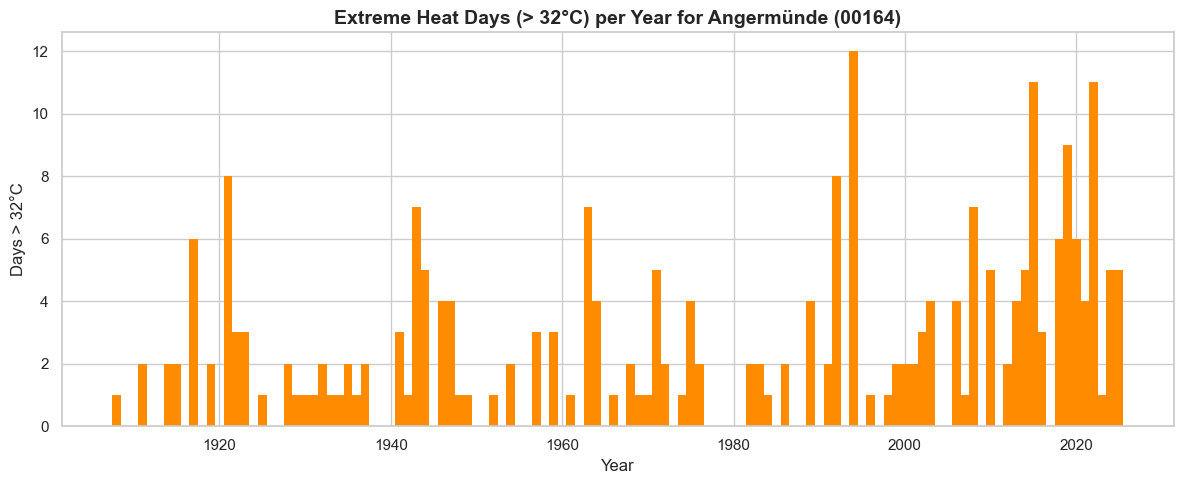

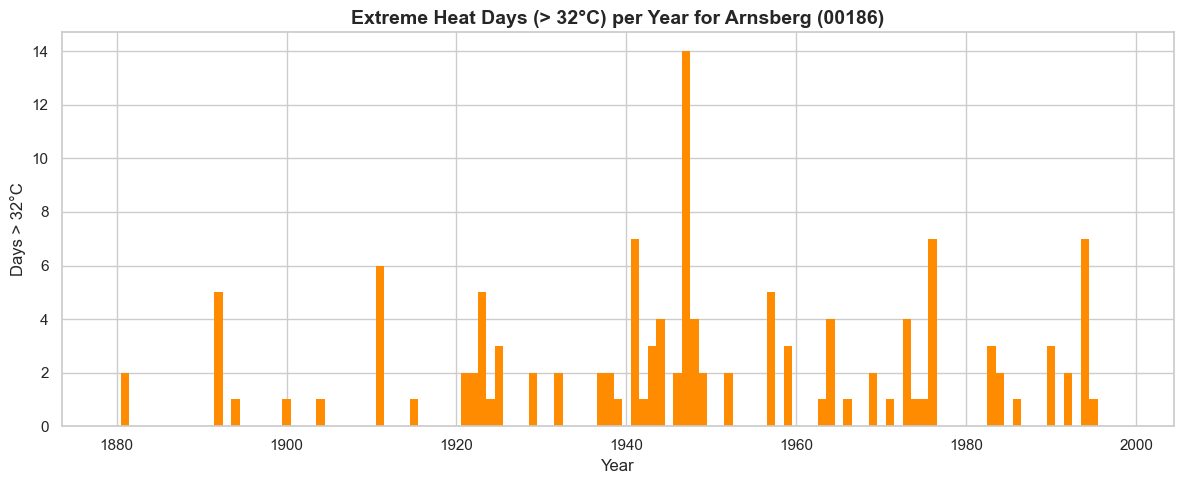

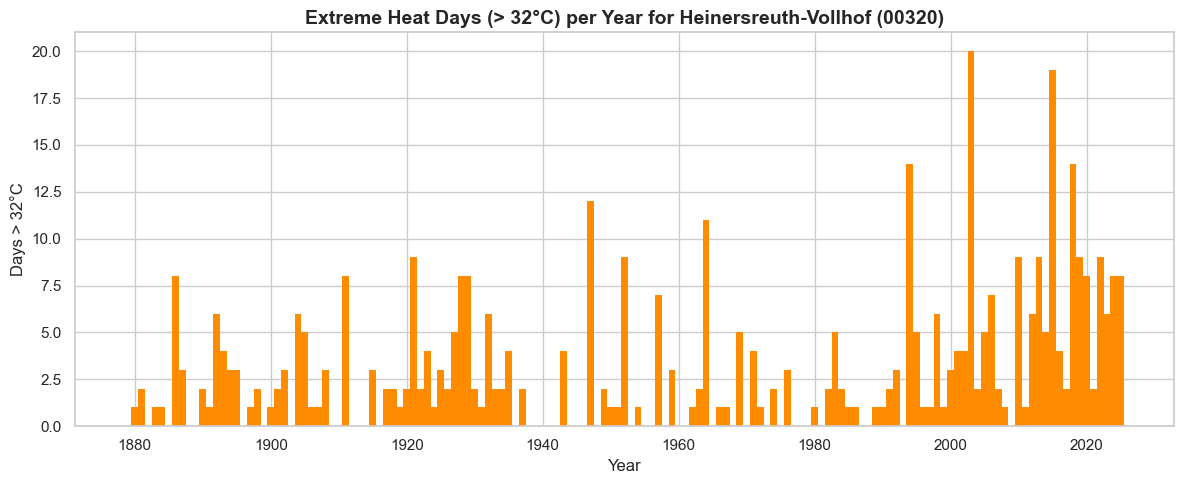

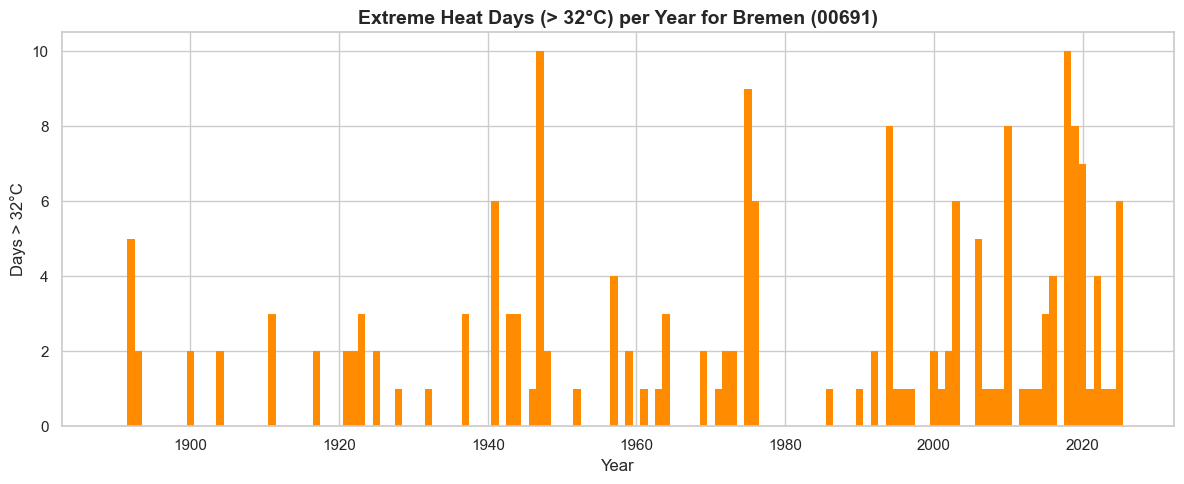

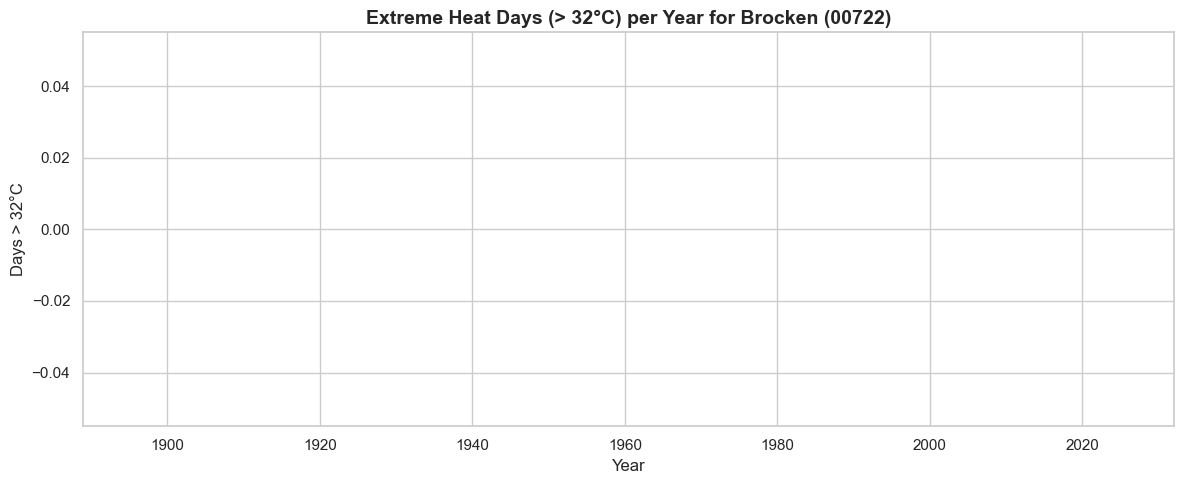

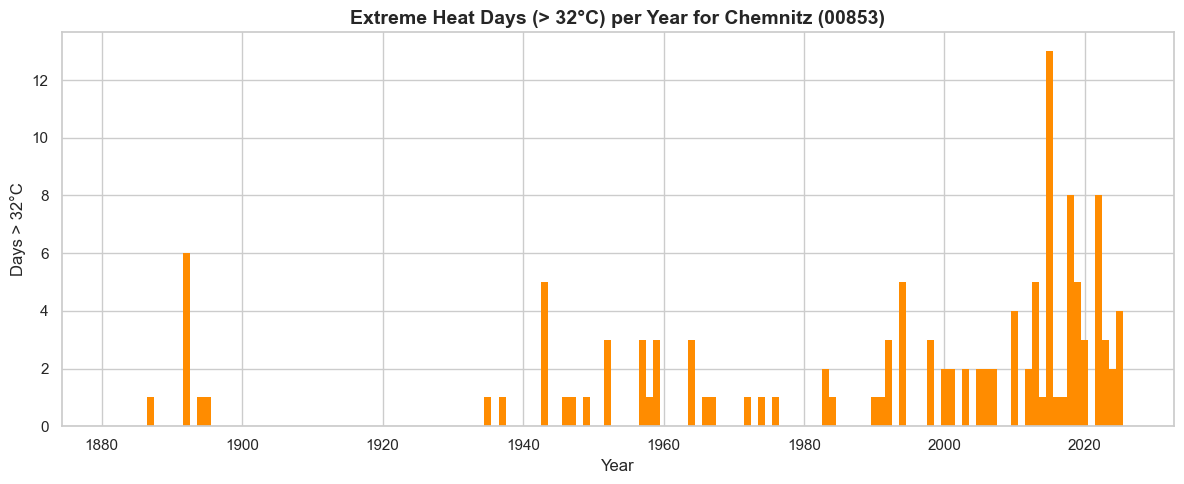

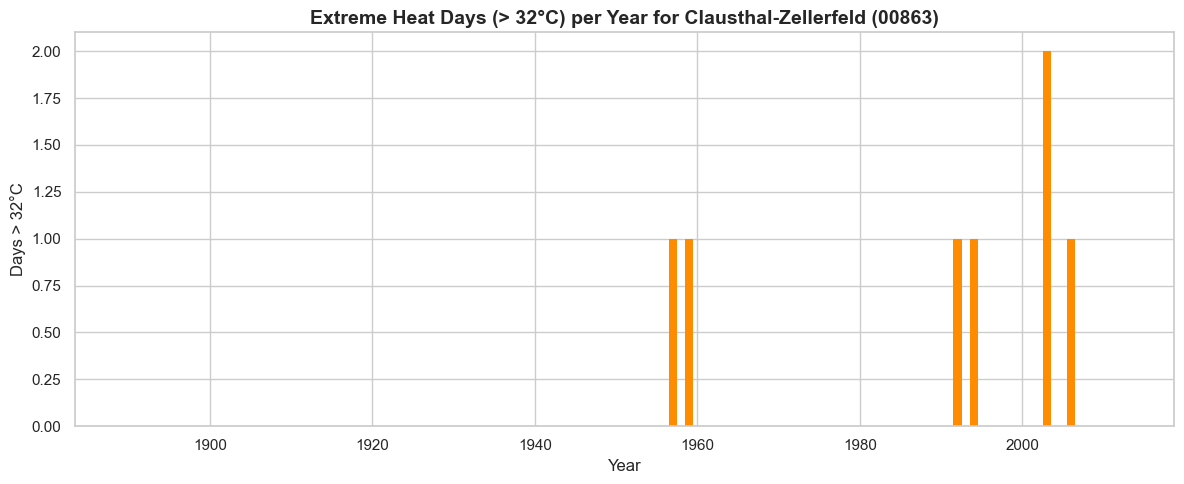

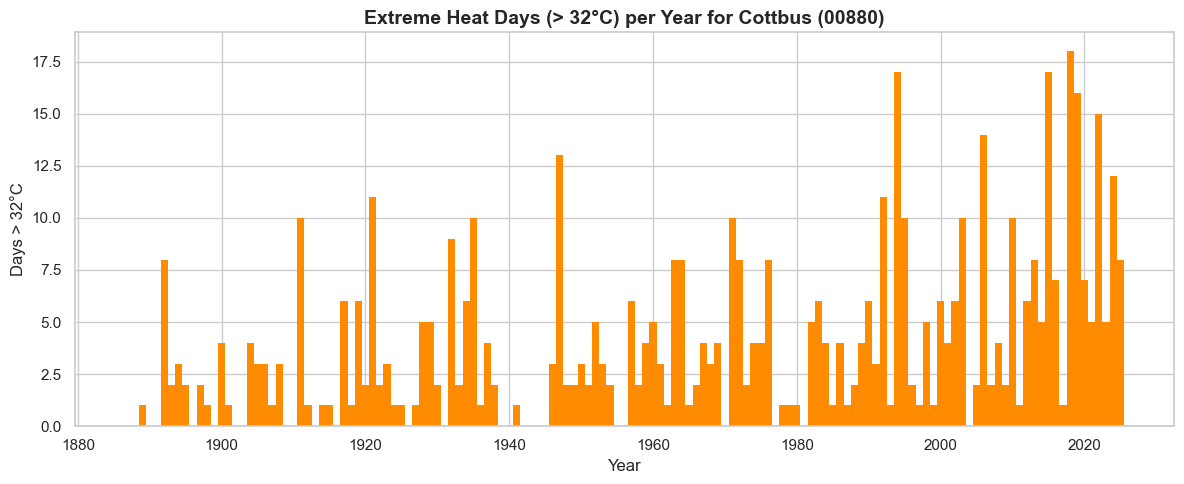

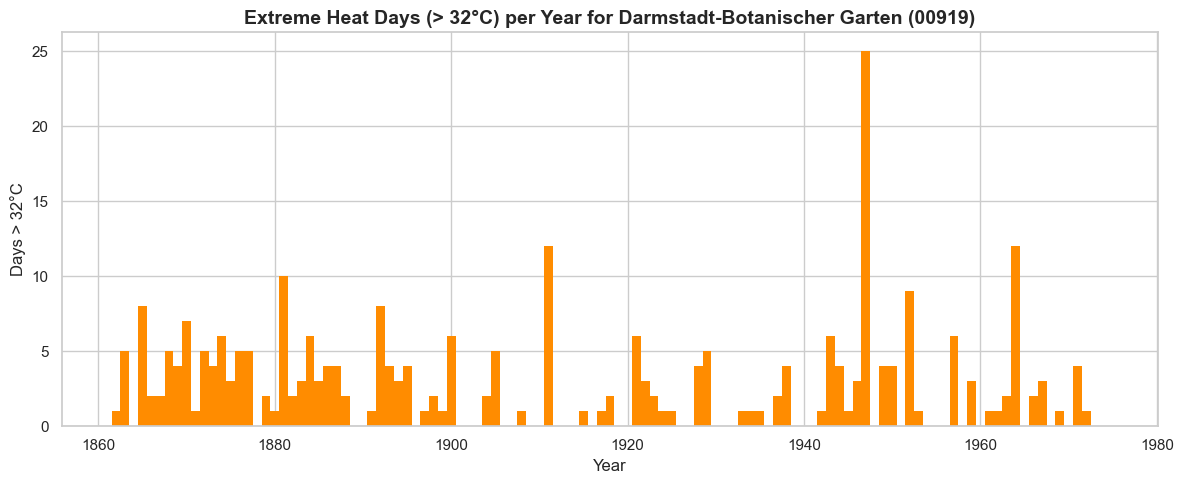

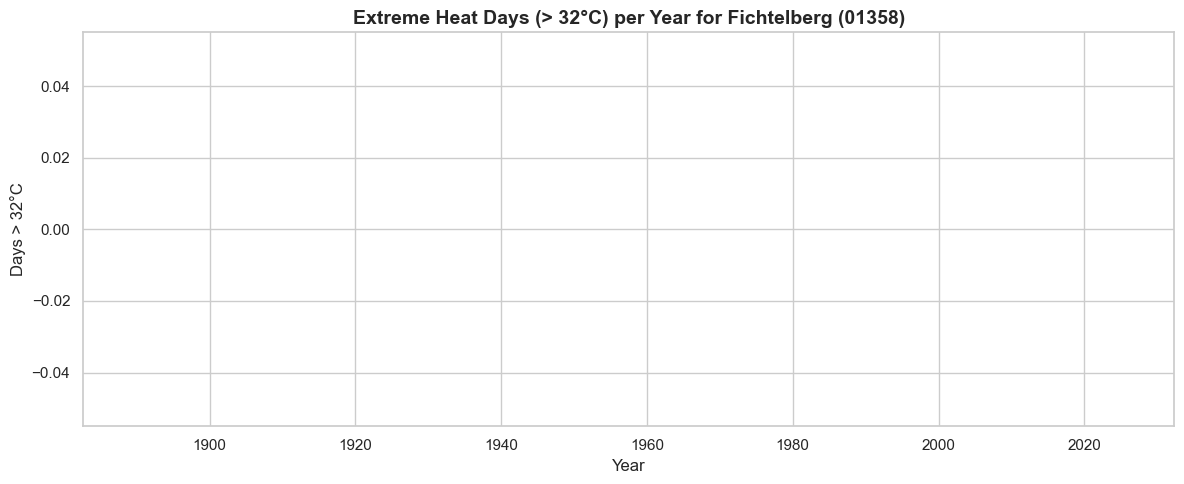

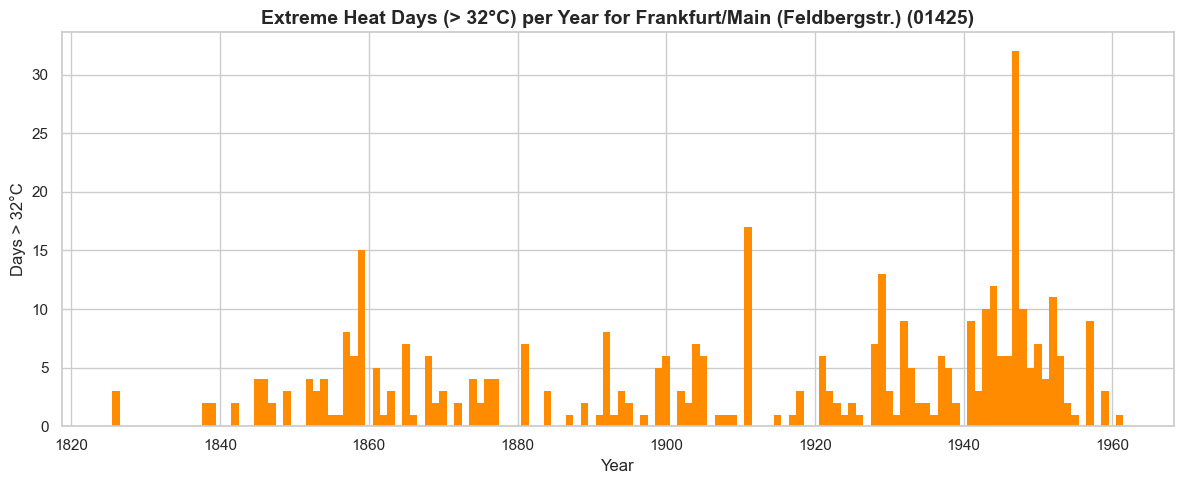

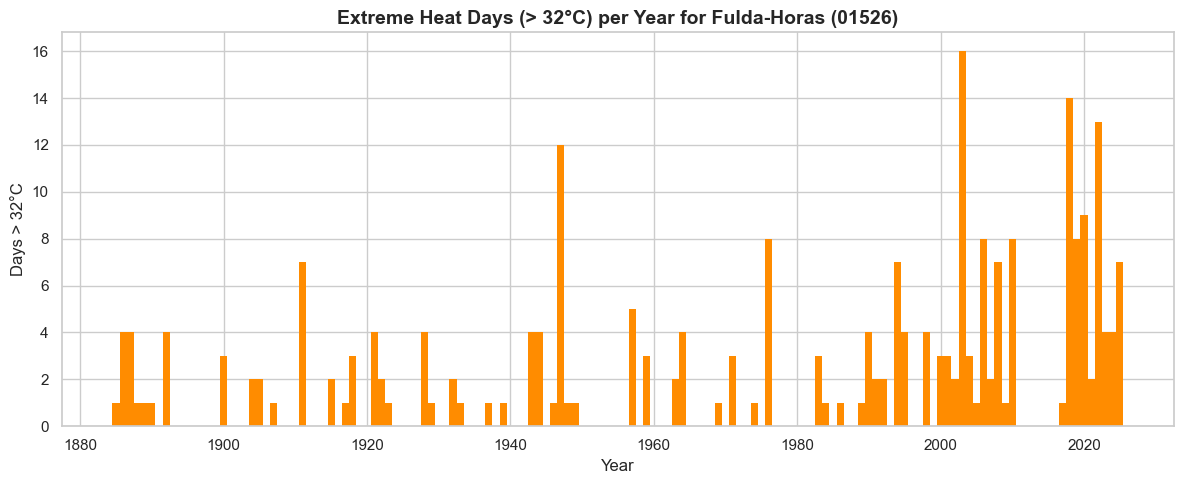

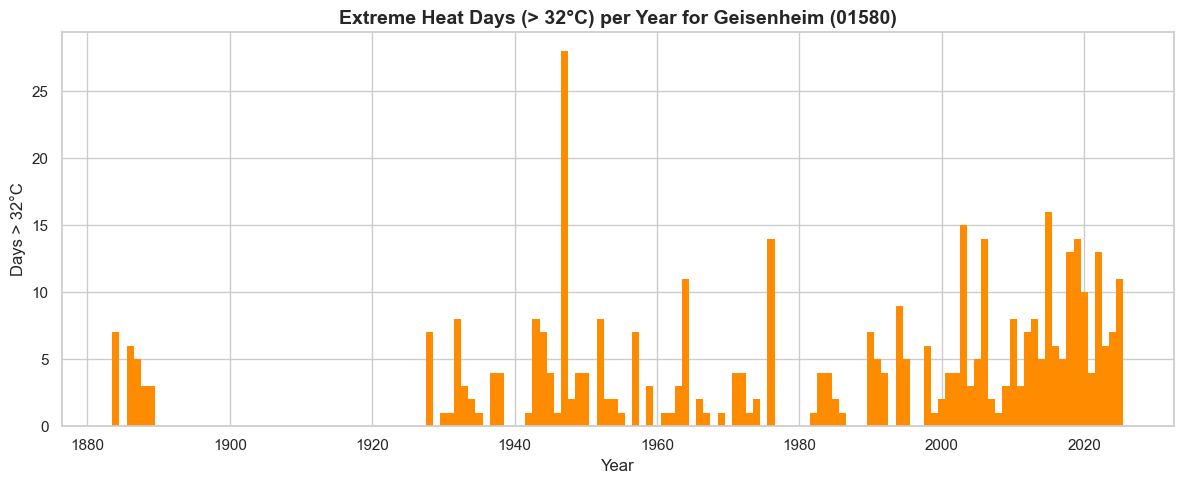

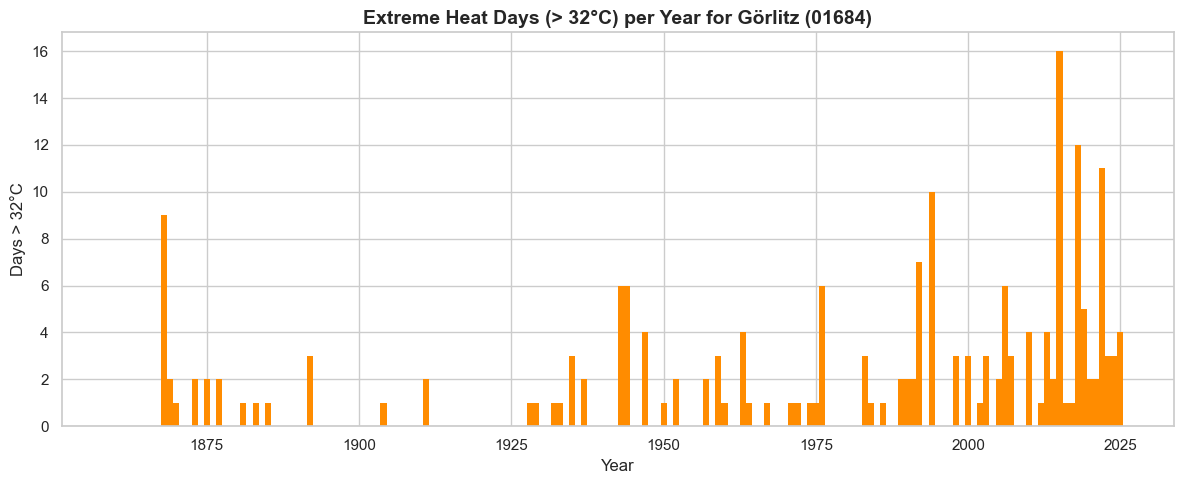

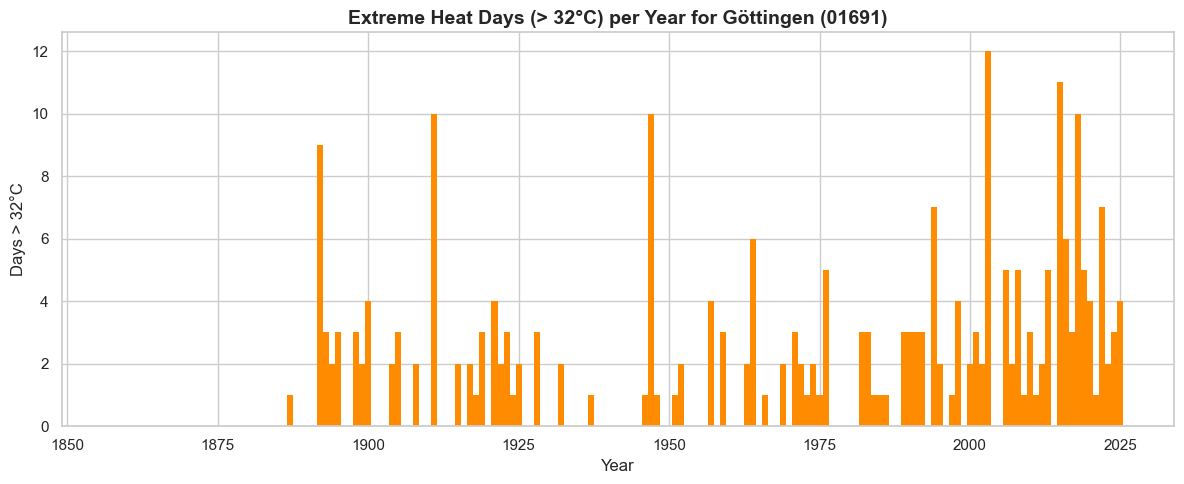

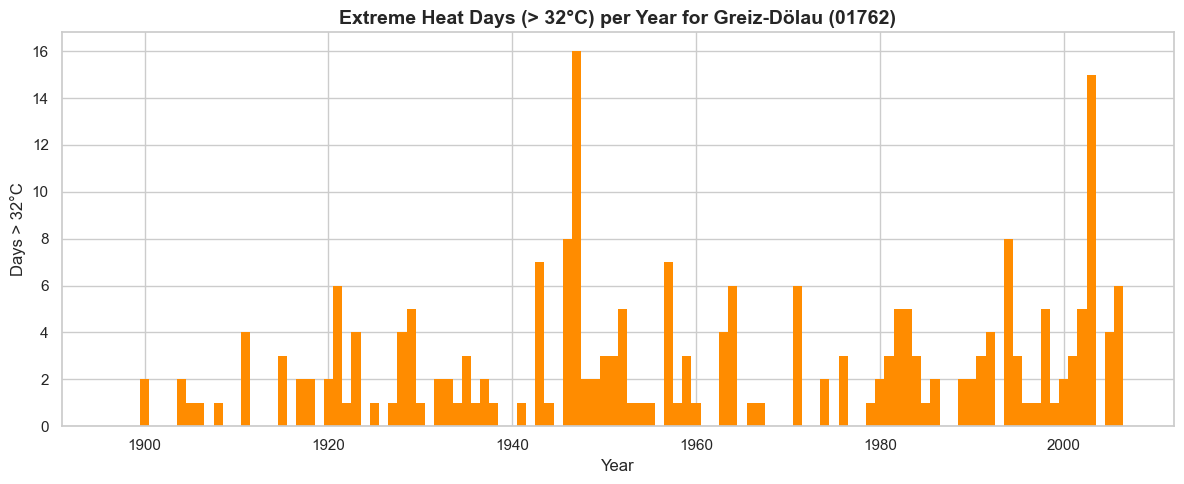

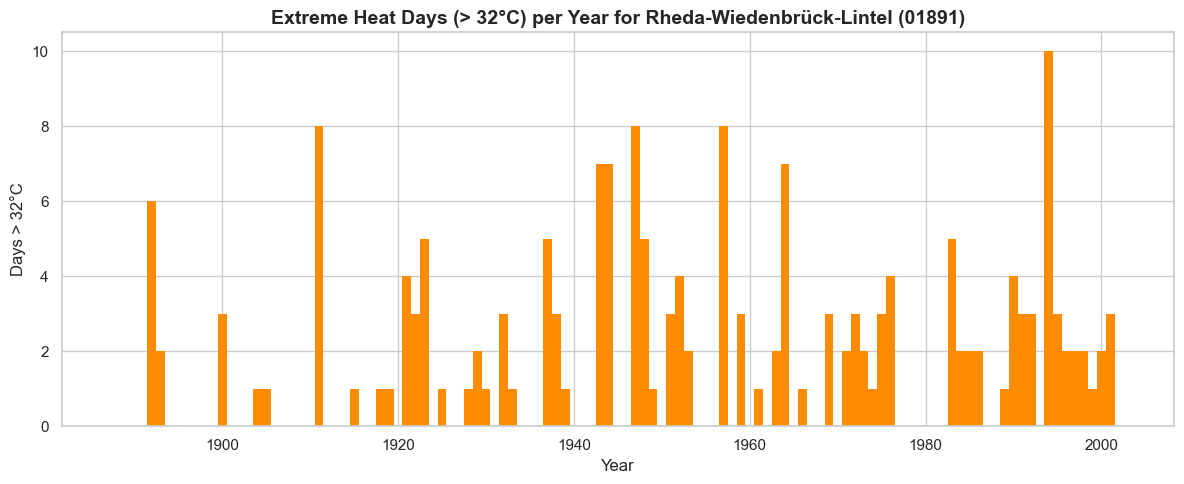

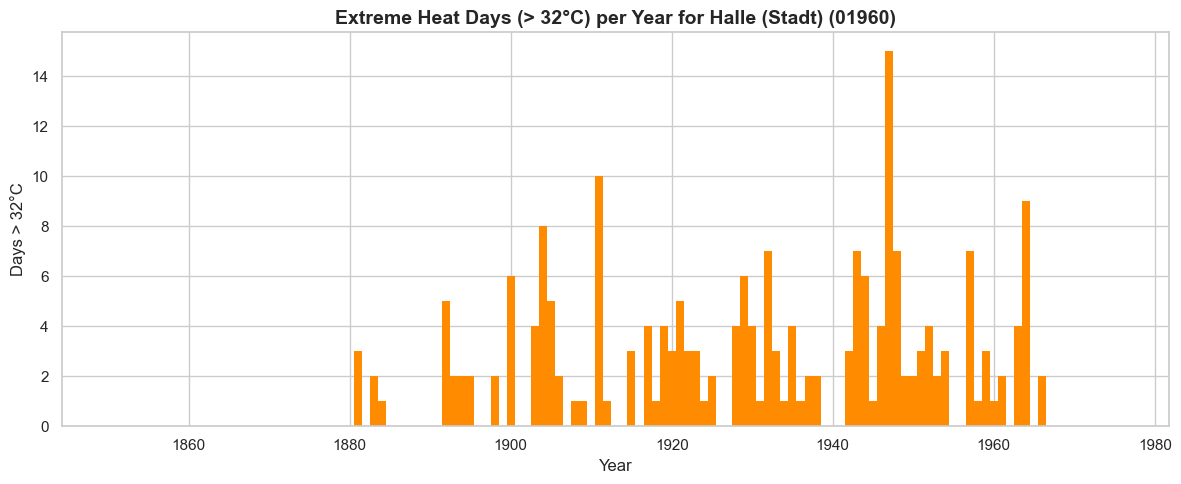

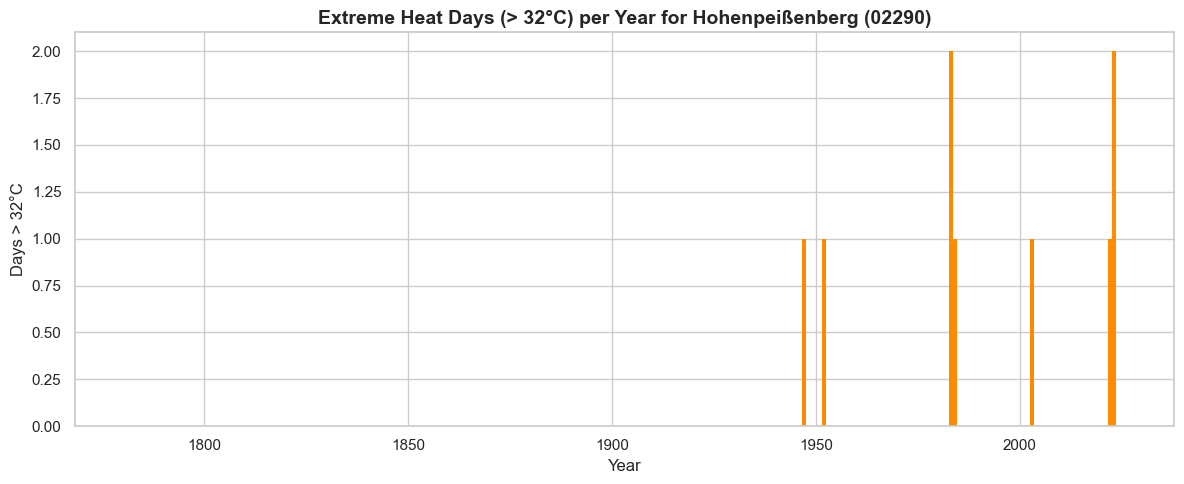

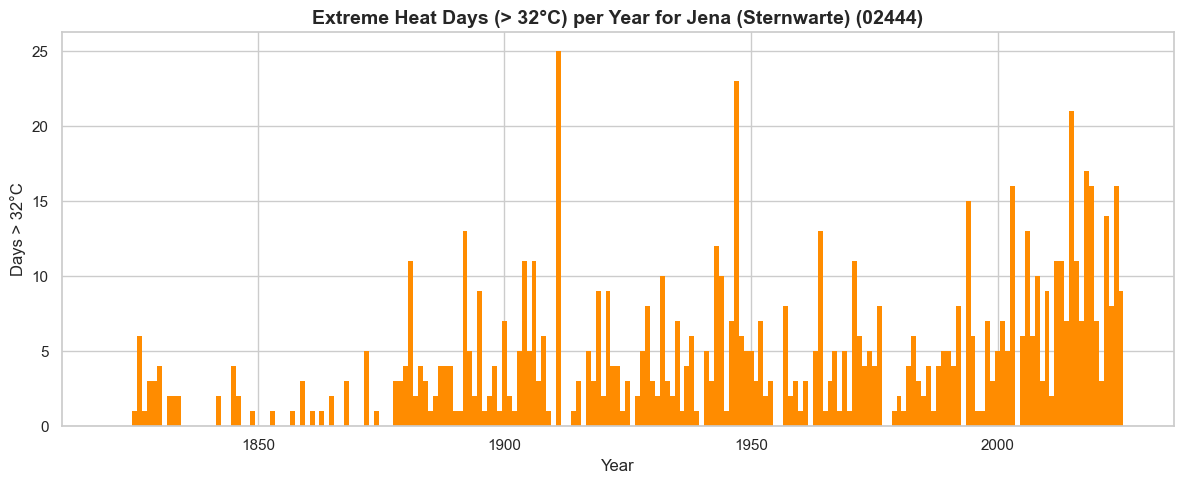

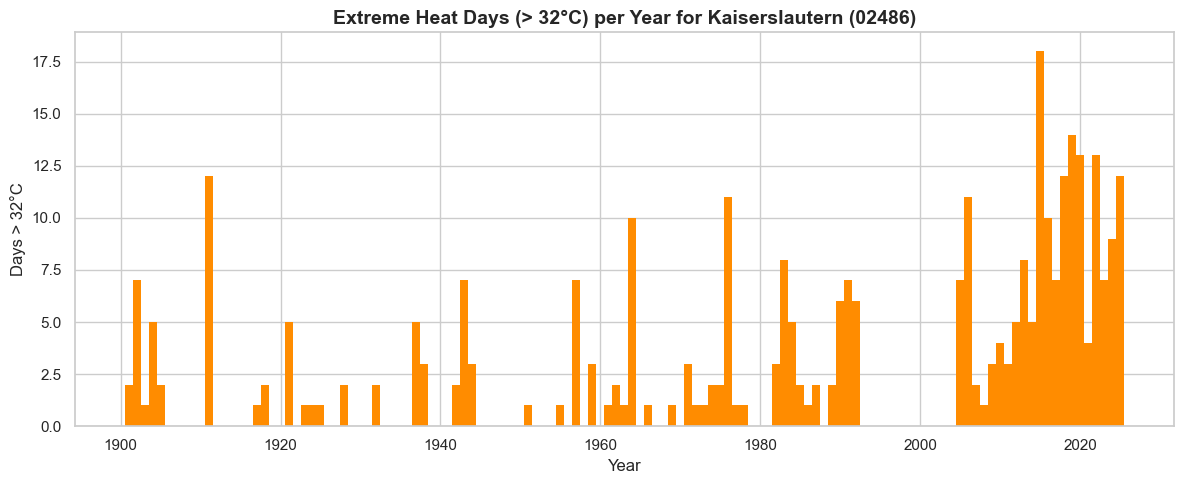

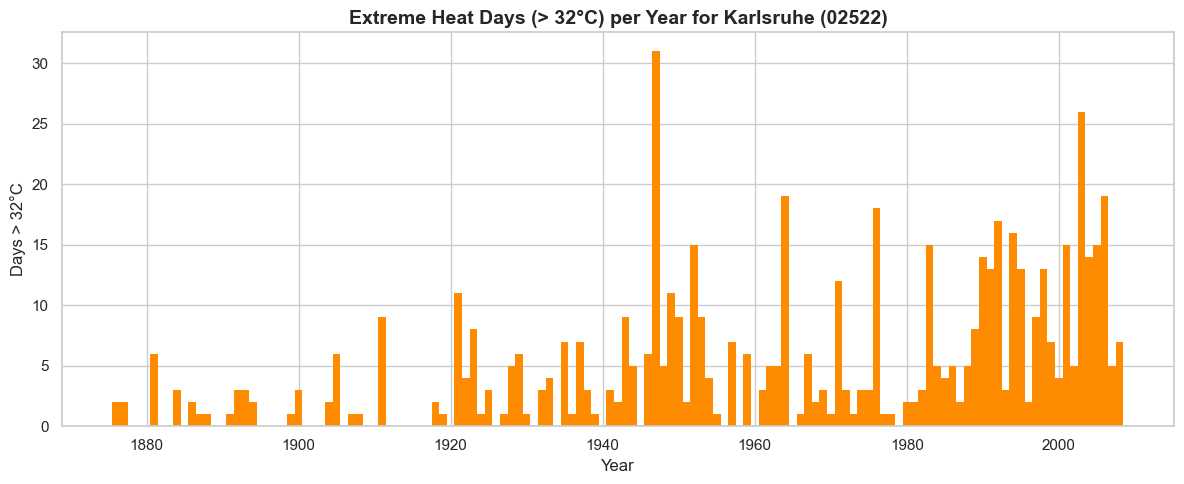

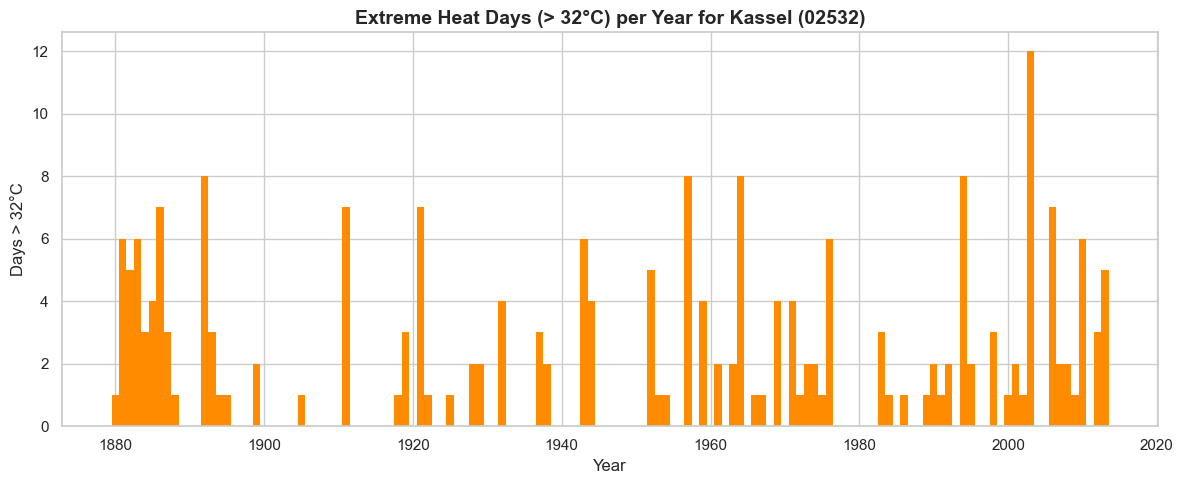

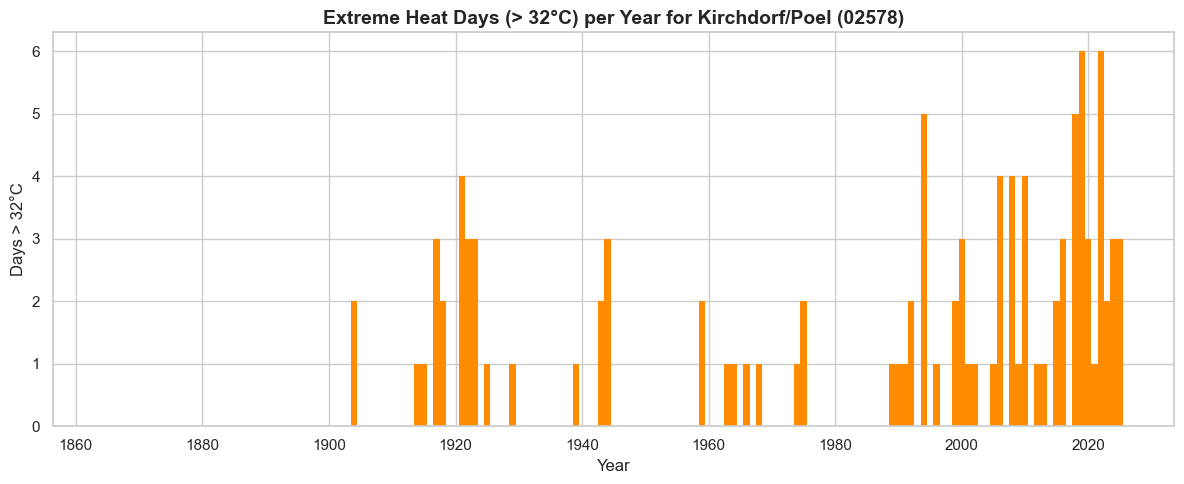

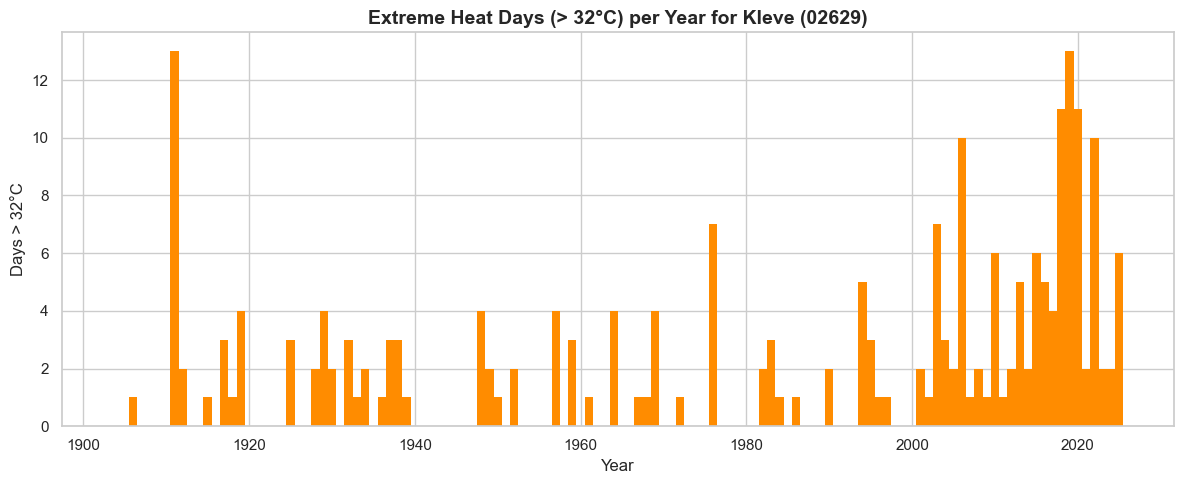

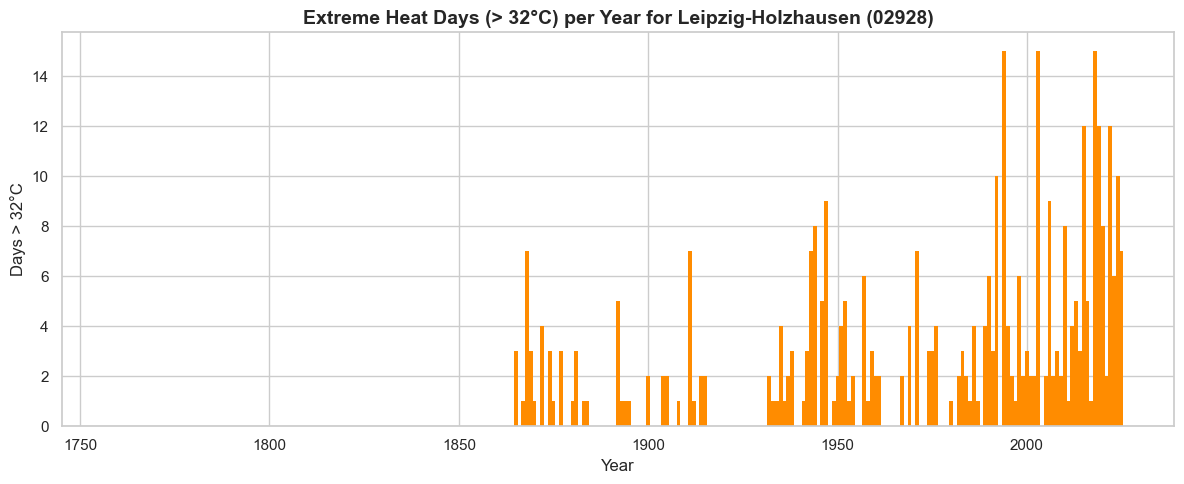

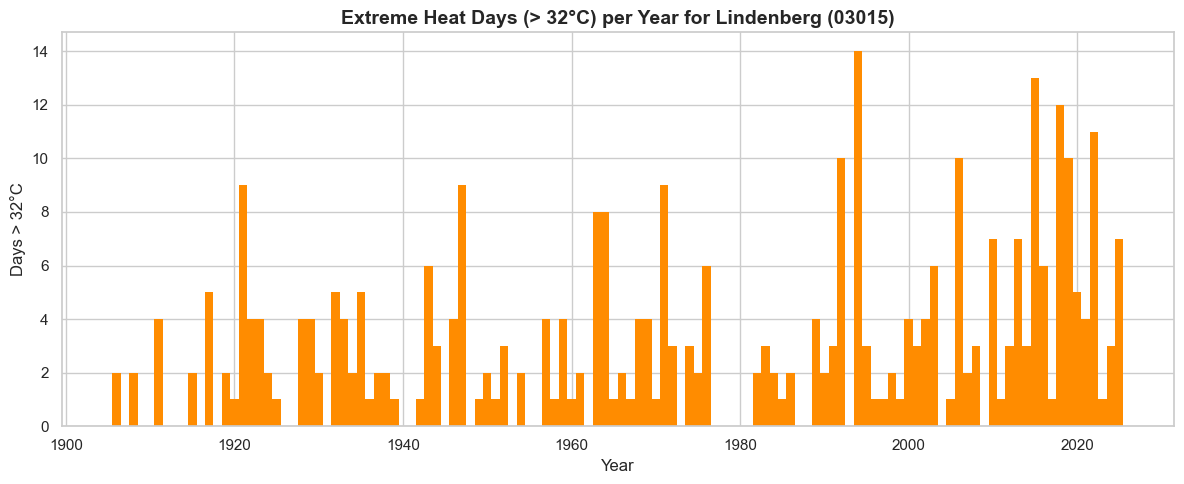

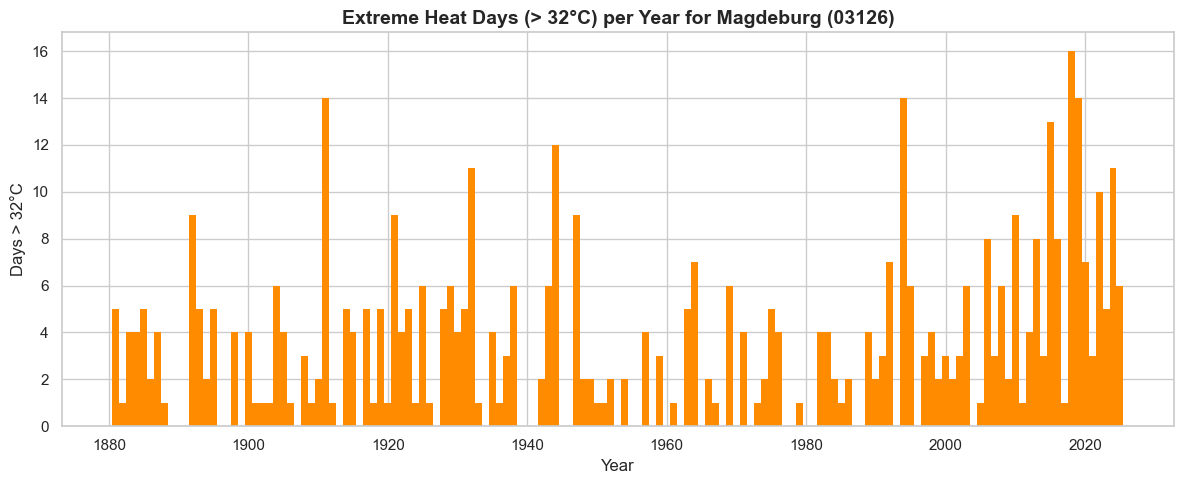

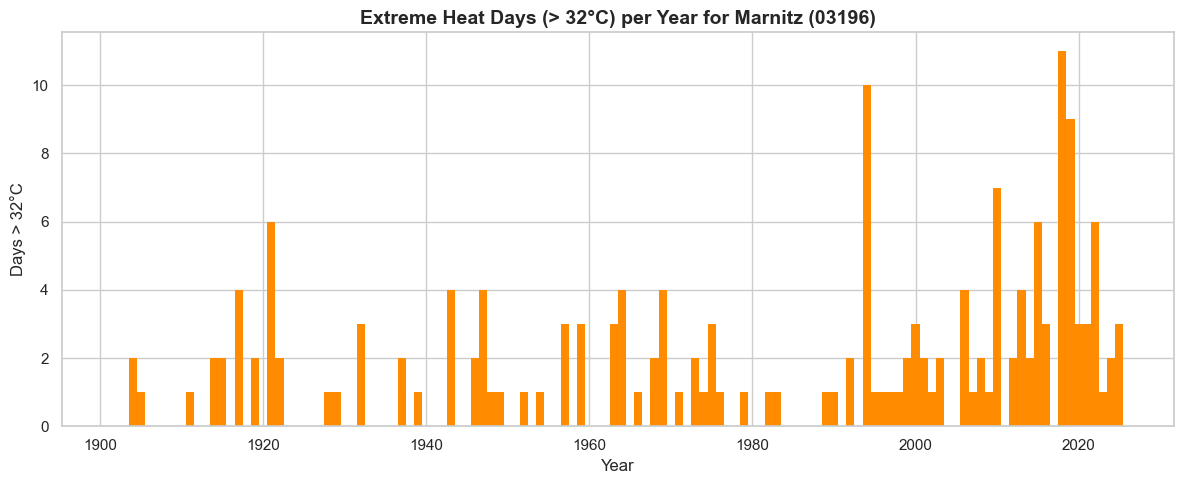

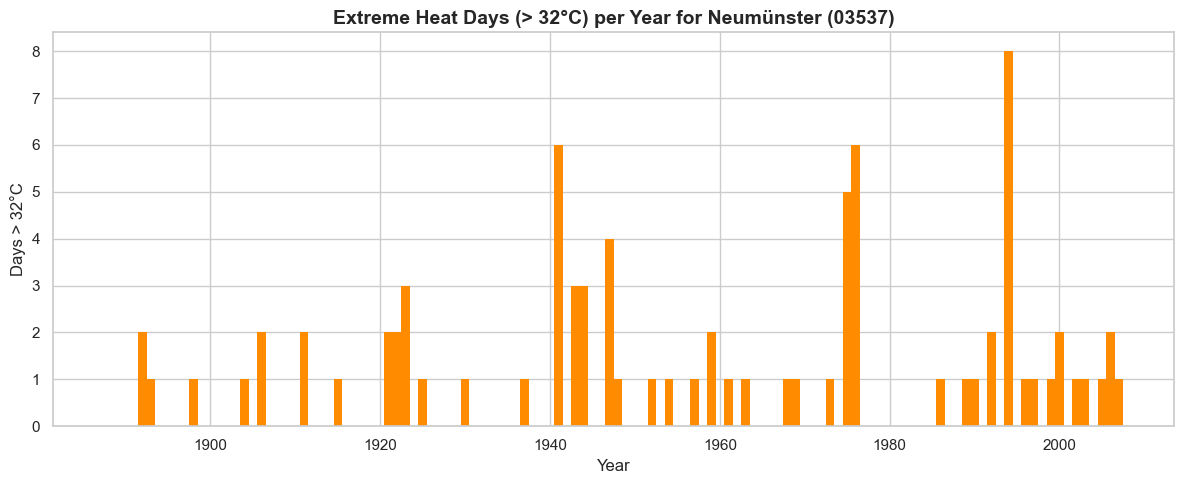

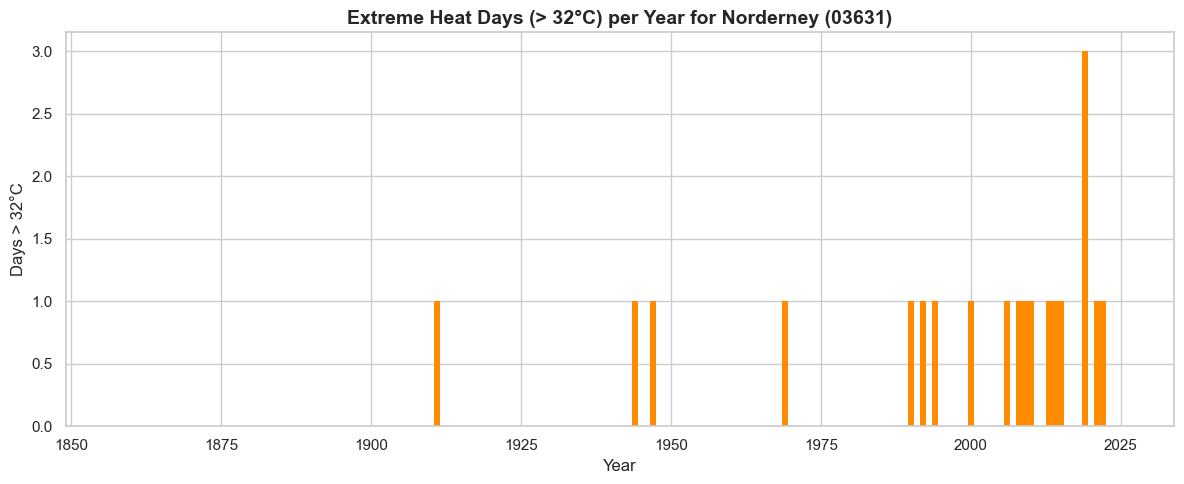

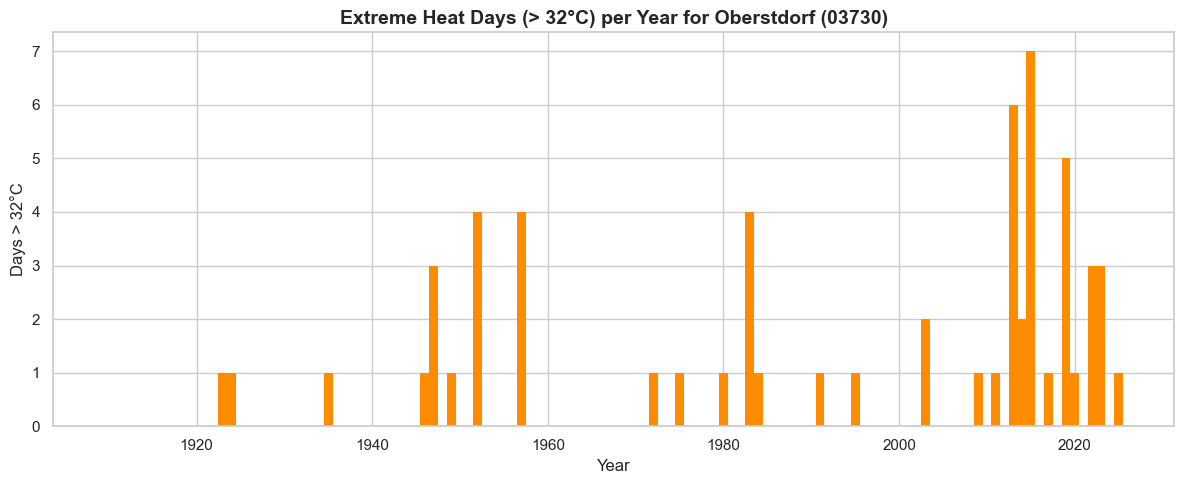

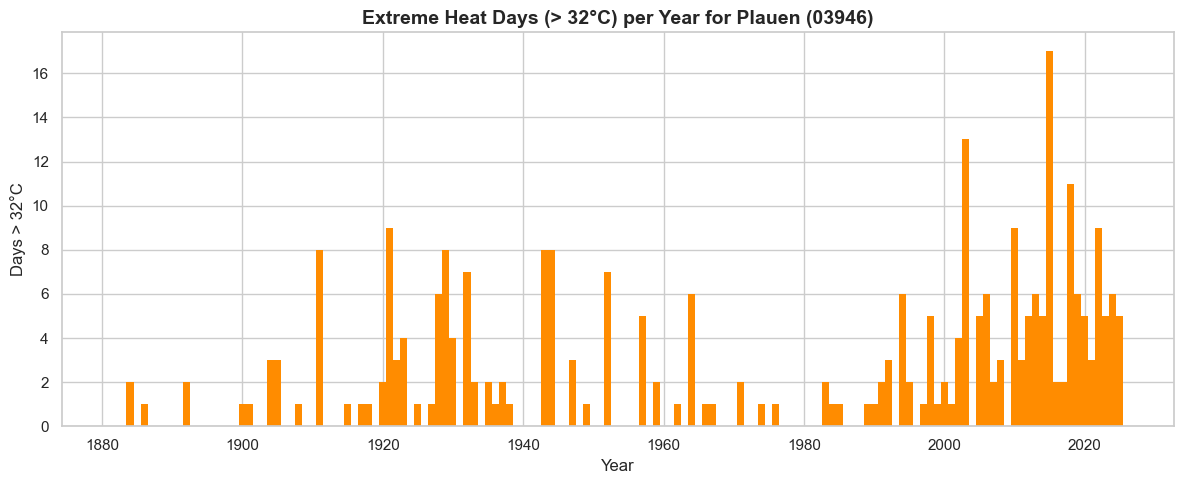

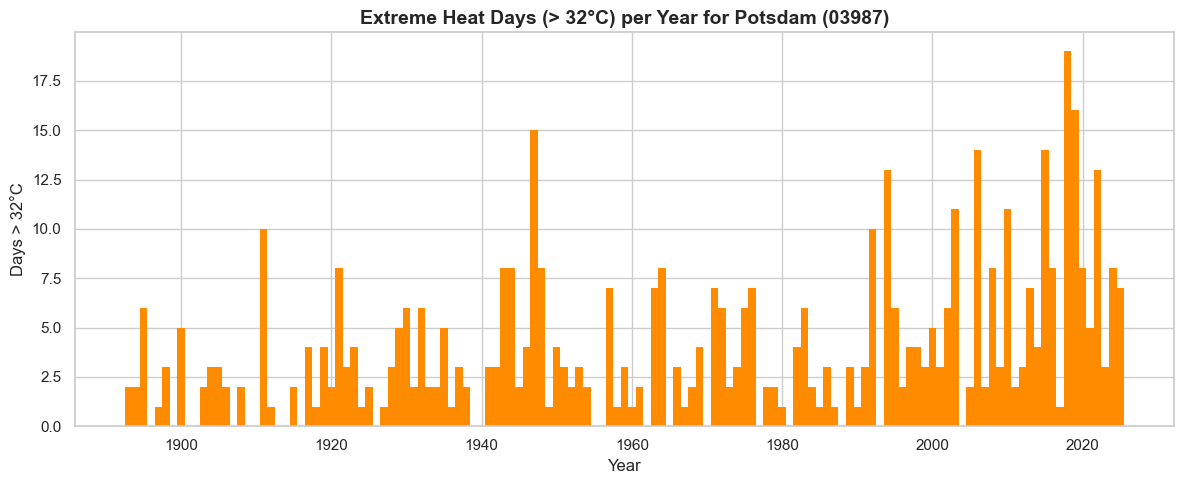

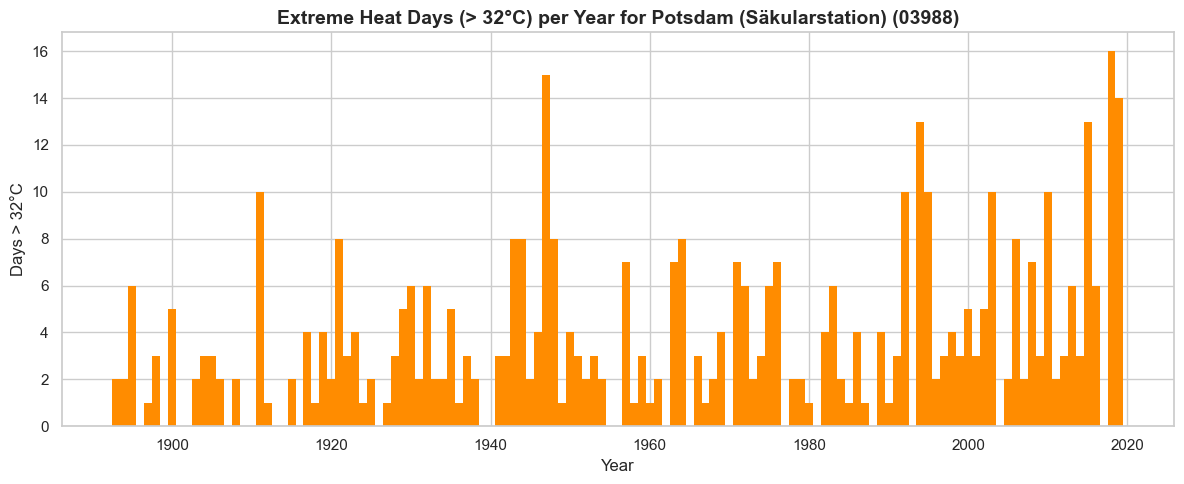

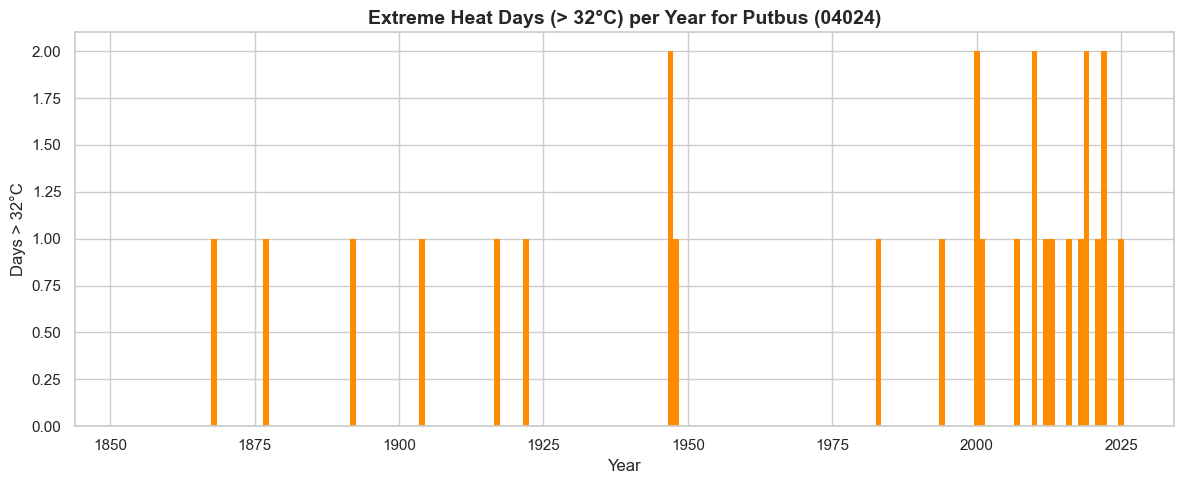

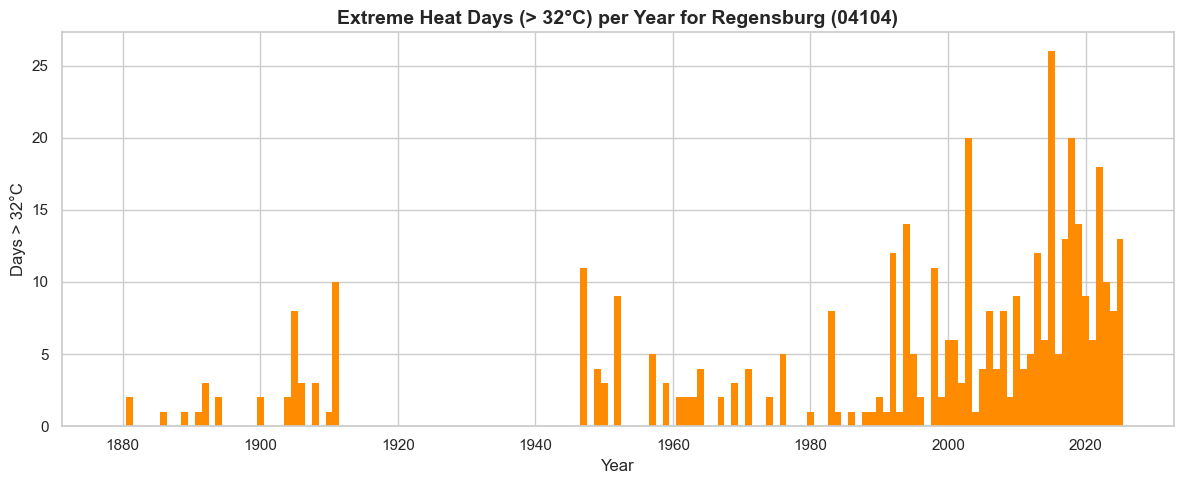

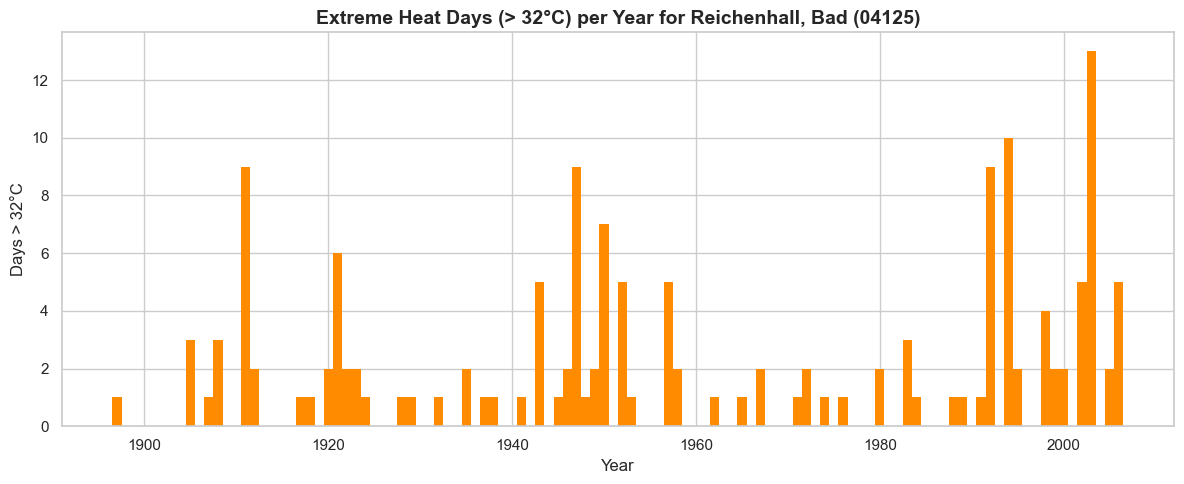

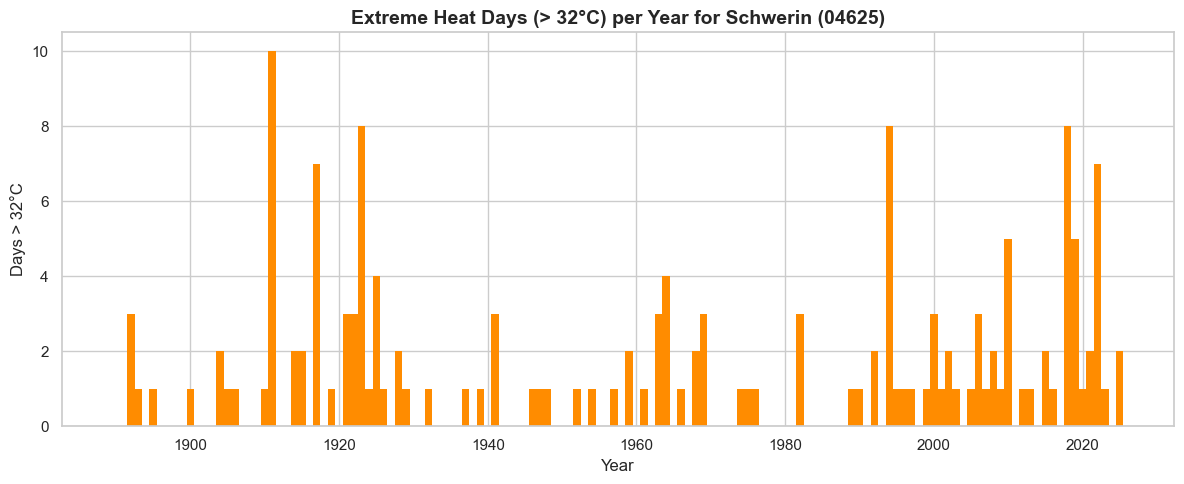

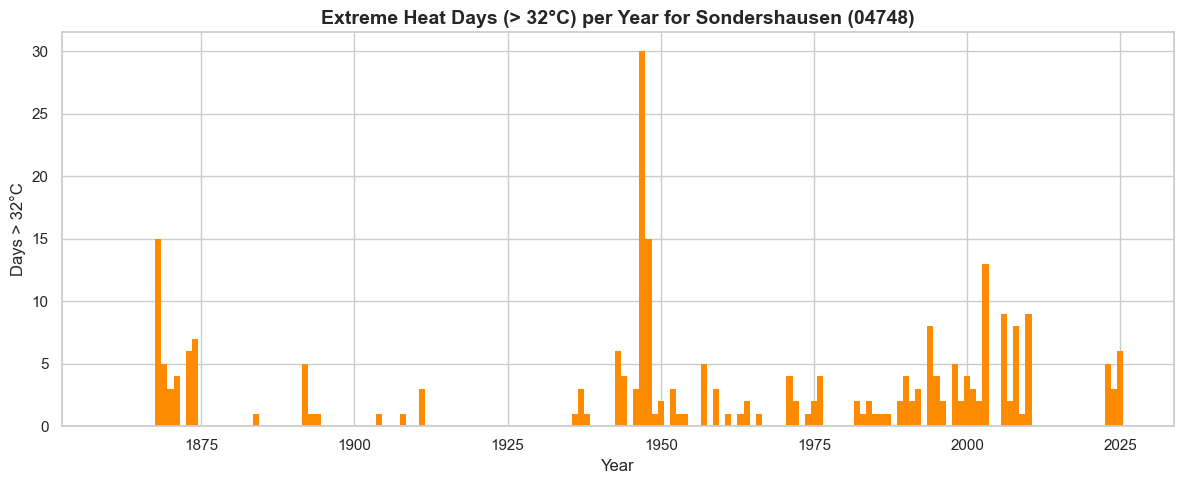

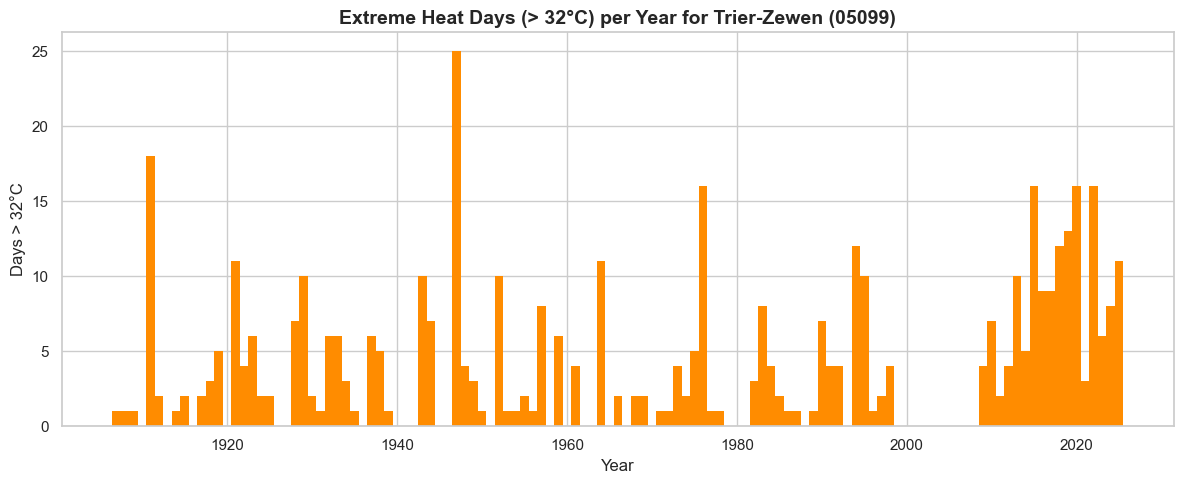

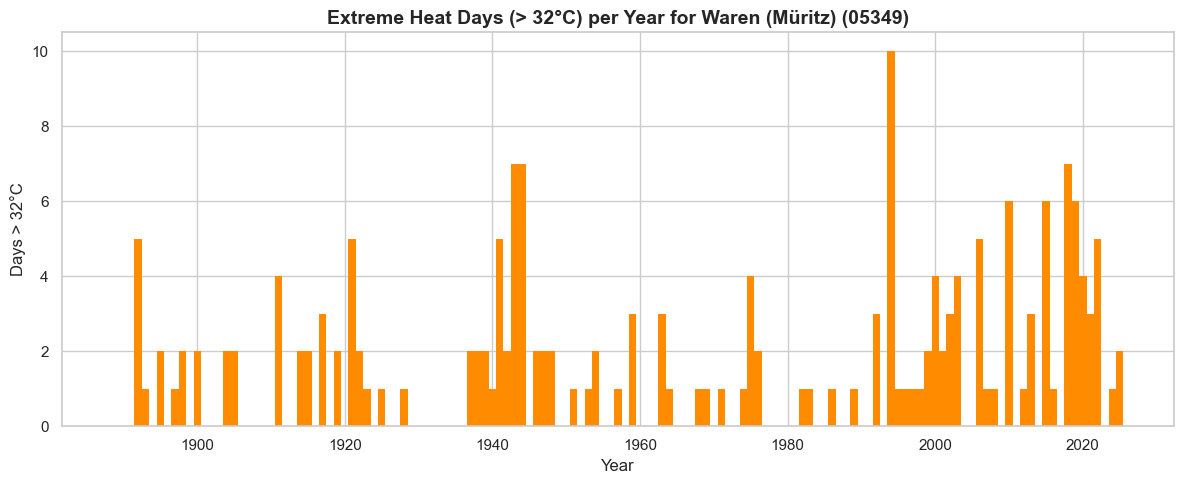

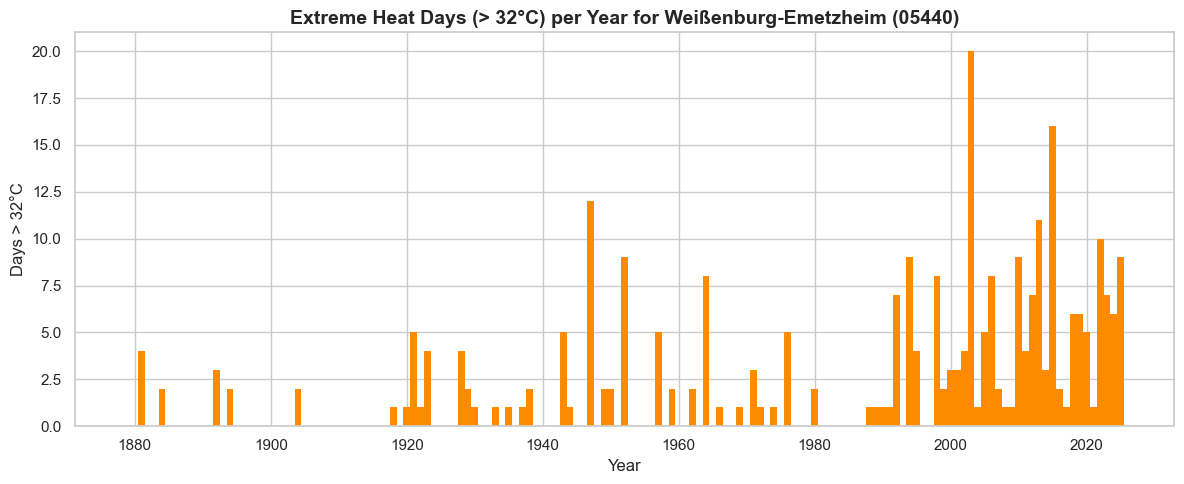

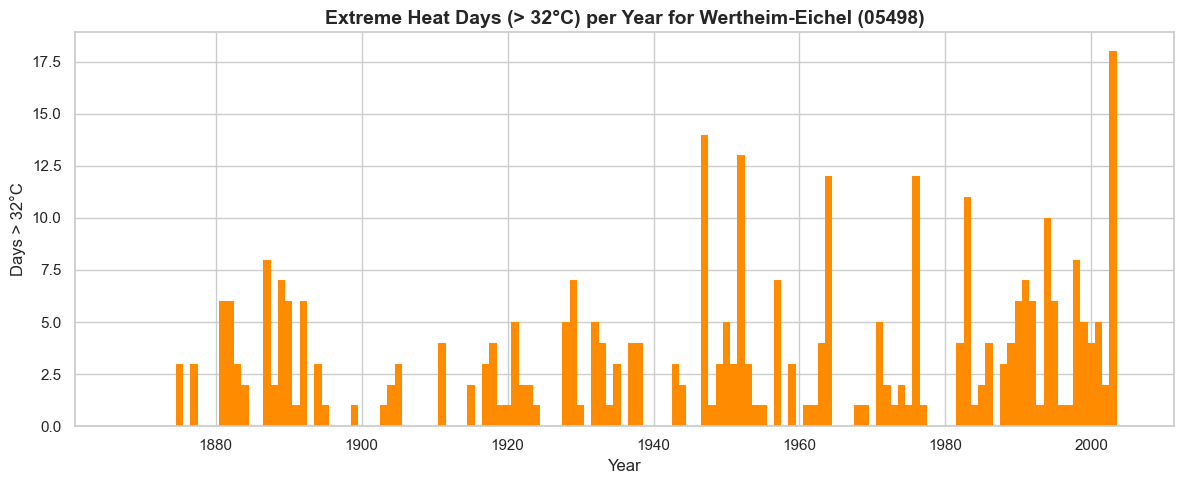

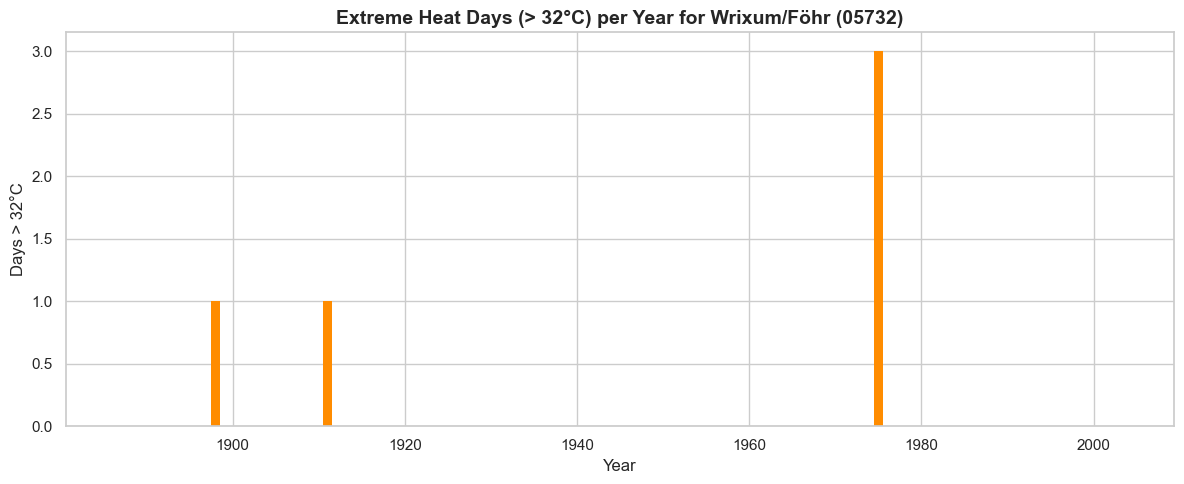

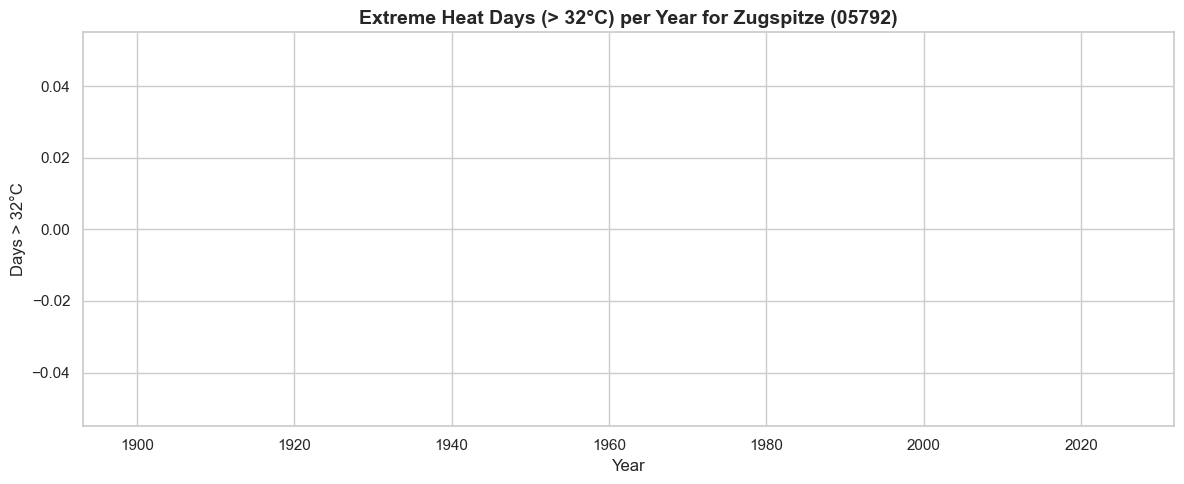

In [2]:
# Load Max_Temp_C for those stations
df_temp = dataset.to_table(columns=['Station_ID', 'Date', 'Max_Temp_C']).to_pandas()
df_100 = df_temp[df_temp['Station_ID'].isin(stations_100)].copy()

# Add Year column
df_100['Year'] = df_100['Date'].dt.year

# Flag days with Max_Temp_C > 32.0
df_100['Is_Hot_Day'] = df_100['Max_Temp_C'] > 32.0

# Calculate total hot days per year for each station
hot_days_per_year = df_100.groupby(['Station_ID', 'Year'])['Is_Hot_Day'].sum().reset_index()

# Plotting loop
for station in stations_100:
    name = name_dict.get(station, 'Unknown')
    station_data = hot_days_per_year[hot_days_per_year['Station_ID'] == station]
    
    plt.figure(figsize=(12, 5))
    
    # Plot the bar chart
    plt.bar(station_data['Year'], station_data['Is_Hot_Day'], color='darkorange', width=1.0, edgecolor='none')
    
    plt.title(f'Extreme Heat Days (> 32°C) per Year for {name} ({station})', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Days > 32°C', fontsize=12)
    
    plt.tight_layout()
    plt.show()